In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import shutil
import boto3
import matplotlib.pyplot as plt
import seaborn as sns

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-02-18 21:35:01.690127


#### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [4]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [5]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

# pd threshold
flt_threshold_pd = 0.6

Project: 20241112-simple-model-test
Task: 13_60_in_720_dl
Subtask: 16_swap_in_swap_out_plots


#### Make output directory

In [6]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import scorecard predictions

In [7]:
list_cols = [
    'accountid',
    'request_datetime',
    'PD',
    'LGD',
    'ECNL',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../03_get_predictions/output/{str_filename}'
df_dlv2 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'LGD': 'lgd_dlv2',
    'PD': 'pd_dlv2',
    'ECNL': 'ecnl_dlv2',
}
df_dlv2.rename(columns=dict_rename, inplace=True)
# show
df_dlv2

,accountid,request_datetime,pd_dlv2,lgd_dlv2,ecnl_dlv2
0,8321703,2024-11-27 21:53:12+00:00,0.226087,0.635684,0.339178
1,8353245,2024-12-04 23:32:24+00:00,0.087583,0.635684,0.131393
2,8375603,2024-12-02 23:02:52+00:00,0.123767,0.605262,0.176791
3,8380765,2024-12-10 04:19:45+00:00,0.239989,0.615474,0.348589
4,8383502,2024-11-27 05:41:46+00:00,0.054071,0.605262,0.077236
...,...,...,...,...,...
9995,8627588,2025-02-07 06:40:52+00:00,0.201369,0.635684,0.302096
9996,8627590,2025-02-07 06:41:04+00:00,0.219424,0.635684,0.329182
9997,8627613,2025-02-07 06:47:03+00:00,0.067110,0.605262,0.095861
9998,8627659,2025-02-07 06:57:18+00:00,0.147441,0.605262,0.210608


#### Get gen12 predictions

In [8]:
list_cols = [
    'accountid',
    'pd',
    'lgd',
    'ecnl',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../04_pricing_distribution/output/{str_filename}'
df_gen12 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'pd': 'pd_gen12',
    'lgd': 'lgd_gen12',
    'ecnl': 'ecnl_gen12'
}
df_gen12.rename(columns=dict_rename, inplace=True)
# show
df_gen12

,accountid,pd_gen12,lgd_gen12,ecnl_gen12
0,8321703,0.115847,0.630854,0.172474
1,8353245,0.089682,0.563194,0.119200
2,8375603,0.043439,0.591126,0.060600
3,8380765,0.131776,0.561194,0.174526
4,8383502,0.036059,0.573853,0.048835
...,...,...,...,...
9995,8627588,0.305816,0.729014,0.526148
9996,8627590,0.303960,0.728410,0.522523
9997,8627613,0.176644,0.654692,0.272928
9998,8627659,0.306193,0.646098,0.466880


In [9]:
# join
df = pd.merge(
    left=df_gen12,
    right=df_dlv2,
    on='accountid',
    how='inner',
)
# save memory
del df_gen12
del df_dlv2
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_dlv2,lgd_dlv2,ecnl_dlv2
0,8321703,0.115847,0.630854,0.172474,2024-11-27 21:53:12+00:00,0.226087,0.635684,0.339178
1,8353245,0.089682,0.563194,0.119200,2024-12-04 23:32:24+00:00,0.087583,0.635684,0.131393
2,8375603,0.043439,0.591126,0.060600,2024-12-02 23:02:52+00:00,0.123767,0.605262,0.176791
3,8380765,0.131776,0.561194,0.174526,2024-12-10 04:19:45+00:00,0.239989,0.615474,0.348589
4,8383502,0.036059,0.573853,0.048835,2024-11-27 05:41:46+00:00,0.054071,0.605262,0.077236
...,...,...,...,...,...,...,...,...
9995,8627588,0.305816,0.729014,0.526148,2025-02-07 06:40:52+00:00,0.201369,0.635684,0.302096
9996,8627590,0.303960,0.728410,0.522523,2025-02-07 06:41:04+00:00,0.219424,0.635684,0.329182
9997,8627613,0.176644,0.654692,0.272928,2025-02-07 06:47:03+00:00,0.067110,0.605262,0.095861
9998,8627659,0.306193,0.646098,0.466880,2025-02-07 06:57:18+00:00,0.147441,0.605262,0.210608


#### Get the raw data

In [10]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/04_parse_payloads_dl/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
df_tmp['amtfinanced__app']= df_tmp['amtfinanced__app'].replace(0, np.nan)
df_tmp['bookvalue__app'] = df_tmp['bookvalue__app'].replace(0, np.nan)
df_tmp['ENG-loan_to_value'] = df_tmp['amtfinanced__app'] / df_tmp['bookvalue__app']
# df_tmp['ENG-loan_to_value'] = df_tmp['ENG-loan_to_value'].replace(0, np.nan)
# df_tmp['ENG-loan_to_value'] = df_tmp['ENG-loan_to_value'].fillna(1.27)

# bk tag
df_tmp['intopenbktype__app'] = df_tmp['intopenbktype__app'].apply(lambda x: 0 if pd.isna(x) else 1)

# franchise tag -- referrals make 0
df_tmp['strdealershiptrackertype__app'] = df_tmp['strdealershiptrackertype__app'].apply(lambda x: 0 if x=='Independent' else 1)

# group
df_tmp = df_tmp.groupby(by='accountid', as_index=False).agg({
    'intopenbktype__app': 'first',
    'ENG-loan_to_value': 'first',
    'strdealershiptrackertype__app': 'first',
    'fltgrossmonthly__income_sum': 'sum',
    'miles_odometer__app': 'first',
})
# show
df_tmp

,accountid,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app
0,8321703,0,1.304611,1,4379.20,69144
1,8353245,0,1.219764,1,8923.01,97249
2,8375603,0,1.101235,1,8233.33,56150
3,8380765,0,1.135986,1,6998.09,30237
4,8383502,0,0.954679,1,10034.96,52621
...,...,...,...,...,...,...
9995,8627588,0,1.243941,1,7401.00,40301
9996,8627590,0,1.217199,1,7500.00,79000
9997,8627613,0,0.993862,1,10833.00,42200
9998,8627659,0,0.967878,1,5400.00,86000


In [11]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='accountid',
    how='left',
)

# get intnrows
int_nrows = df.shape[0]

# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_dlv2,lgd_dlv2,ecnl_dlv2,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app
0,8321703,0.115847,0.630854,0.172474,2024-11-27 21:53:12+00:00,0.226087,0.635684,0.339178,0,1.304611,1,4379.20,69144
1,8353245,0.089682,0.563194,0.119200,2024-12-04 23:32:24+00:00,0.087583,0.635684,0.131393,0,1.219764,1,8923.01,97249
2,8375603,0.043439,0.591126,0.060600,2024-12-02 23:02:52+00:00,0.123767,0.605262,0.176791,0,1.101235,1,8233.33,56150
3,8380765,0.131776,0.561194,0.174526,2024-12-10 04:19:45+00:00,0.239989,0.615474,0.348589,0,1.135986,1,6998.09,30237
4,8383502,0.036059,0.573853,0.048835,2024-11-27 05:41:46+00:00,0.054071,0.605262,0.077236,0,0.954679,1,10034.96,52621
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8627588,0.305816,0.729014,0.526148,2025-02-07 06:40:52+00:00,0.201369,0.635684,0.302096,0,1.243941,1,7401.00,40301
9996,8627590,0.303960,0.728410,0.522523,2025-02-07 06:41:04+00:00,0.219424,0.635684,0.329182,0,1.217199,1,7500.00,79000
9997,8627613,0.176644,0.654692,0.272928,2025-02-07 06:47:03+00:00,0.067110,0.605262,0.095861,0,0.993862,1,10833.00,42200
9998,8627659,0.306193,0.646098,0.466880,2025-02-07 06:57:18+00:00,0.147441,0.605262,0.210608,0,0.967878,1,5400.00,86000


#### Create tier

In [12]:
# gen 12
df['tier_gen12'] = df['ecnl_gen12'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# gen 13
df['tier_dlv2'] = df['ecnl_dlv2'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_dlv2,lgd_dlv2,ecnl_dlv2,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app,tier_gen12,tier_dlv2
0,8321703,0.115847,0.630854,0.172474,2024-11-27 21:53:12+00:00,0.226087,0.635684,0.339178,0,1.304611,1,4379.20,69144,B,D
1,8353245,0.089682,0.563194,0.119200,2024-12-04 23:32:24+00:00,0.087583,0.635684,0.131393,0,1.219764,1,8923.01,97249,A,A
2,8375603,0.043439,0.591126,0.060600,2024-12-02 23:02:52+00:00,0.123767,0.605262,0.176791,0,1.101235,1,8233.33,56150,A1,B
3,8380765,0.131776,0.561194,0.174526,2024-12-10 04:19:45+00:00,0.239989,0.615474,0.348589,0,1.135986,1,6998.09,30237,B,D
4,8383502,0.036059,0.573853,0.048835,2024-11-27 05:41:46+00:00,0.054071,0.605262,0.077236,0,0.954679,1,10034.96,52621,A1,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8627588,0.305816,0.729014,0.526148,2025-02-07 06:40:52+00:00,0.201369,0.635684,0.302096,0,1.243941,1,7401.00,40301,Decline,C
9996,8627590,0.303960,0.728410,0.522523,2025-02-07 06:41:04+00:00,0.219424,0.635684,0.329182,0,1.217199,1,7500.00,79000,Decline,D
9997,8627613,0.176644,0.654692,0.272928,2025-02-07 06:47:03+00:00,0.067110,0.605262,0.095861,0,0.993862,1,10833.00,42200,C,A
9998,8627659,0.306193,0.646098,0.466880,2025-02-07 06:57:18+00:00,0.147441,0.605262,0.210608,0,0.967878,1,5400.00,86000,Decline,B


#### LTV

In [13]:
# cap all ltv to 1.27
df['ENG-loan_to_value'] = df['ENG-loan_to_value'].apply(lambda x: min(x, 1.27))

# gen 12
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'ENG-loan_to_value': 'mean',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'ENG-loan_to_value':'gen12_mean_LTV'}, inplace=True)

# gen 13
df_tmp2 = df.groupby(by=['tier_dlv2'], as_index=False).agg({
    'ENG-loan_to_value': 'mean',
})

df_tmp2.rename(columns={'tier_dlv2':'Tier', 'ENG-loan_to_value':'dlv2_mean_LTV'},  inplace=True)

In [14]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values



# show
df_tmp

,Tier,gen12_mean_LTV,dlv2_mean_LTV
0,A1,0.943195,0.627786
1,A,1.020953,1.065062
2,B,1.088027,1.182814
3,C,1.118992,1.221462
4,D,1.142253,1.230542
5,Decline,1.178446,1.244816


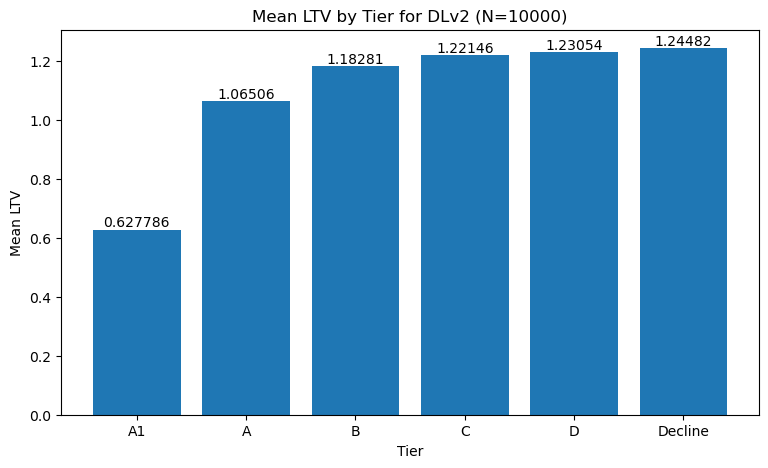

In [15]:
# # melt
# df_melted = df_tmp.melt(id_vars='Tier', var_name='LTV', value_name='Average LTV')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean LTV by Tier for DLv2 (N={int_nrows})')
ax.set_ylabel('Mean LTV')
ax.set_xlabel('Tier')
bars = ax.bar(df_tmp['Tier'], df_tmp['dlv2_mean_LTV'])
ax.bar_label(bars)

# save
str_filename = 'plt_stacked_ltv.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### Income

In [16]:
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'fltgrossmonthly__income_sum': 'median',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'fltgrossmonthly__income_sum':'gen12_median_income'}, inplace=True)

df_tmp2 = df.groupby(by=['tier_dlv2'], as_index=False).agg({
    'fltgrossmonthly__income_sum': 'median',
})

df_tmp2.rename(columns={'tier_dlv2':'Tier', 'fltgrossmonthly__income_sum':'dlv2_median_income'},  inplace=True)

In [17]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values

# show
df_tmp

,Tier,gen12_median_income,dlv2_median_income
0,A1,8750.0,6667.0
1,A,7500.0,7374.0
2,B,6666.0,6333.0
3,C,6000.0,5833.0
4,D,6250.0,5429.5
5,Decline,5417.0,5333.0


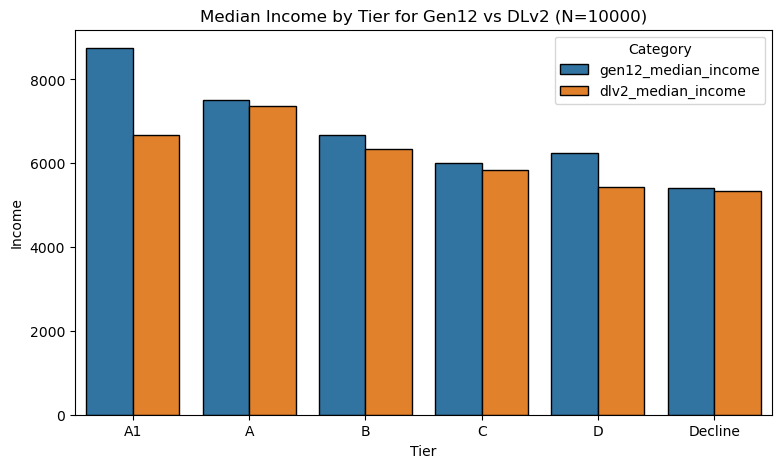

In [18]:
# melt
df_melted = df_tmp.melt(id_vars='Tier', var_name='Median Income', value_name='Income')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Median Income by Tier for Gen12 vs DLv2 (N={int_nrows})')
sns.barplot(x='Tier', y='Income', hue='Median Income', data=df_melted, estimator=sum, edgecolor='black')
plt.legend(title='Category', loc='upper right')

# save
str_filename = 'plt_stacked_income.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### BK frequency

In [19]:
# filter
df_filtered = df[df['tier_gen12'] != 'Decline']
df_filtered2 = df[df['tier_dlv2'] != 'Decline']

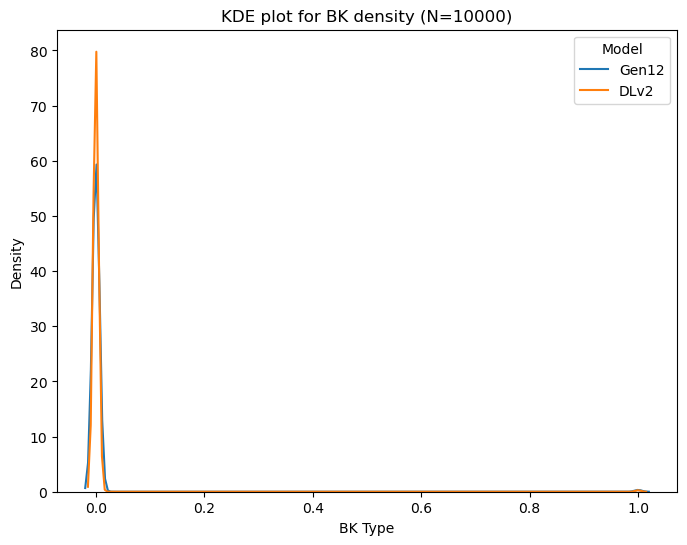

In [20]:
# kde plot
plt.figure(figsize=(8, 6))
sns.kdeplot(df_filtered['intopenbktype__app'], bw_adjust=0.5, fill=False, label='Gen12')
sns.kdeplot(df_filtered2['intopenbktype__app'], bw_adjust=0.5, fill=False, label='DLv2')

# labels
plt.xlabel('BK Type')
plt.ylabel('Density')
plt.title(f'KDE plot for BK density (N={int_nrows})')
plt.legend(title='Model', loc='upper right')

# show
plt.show()

#### BK Tag

In [21]:
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'intopenbktype__app': 'mean',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'intopenbktype__app':'gen12_mean_bk_prop'}, inplace=True)

df_tmp2 = df.groupby(by=['tier_dlv2'], as_index=False).agg({
    'intopenbktype__app': 'mean',
})

df_tmp2.rename(columns={'tier_dlv2':'Tier', 'intopenbktype__app':'dlv2_mean_bk_prop'},  inplace=True)

In [22]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values

# show
df_tmp

,Tier,gen12_mean_bk_prop,dlv2_mean_bk_prop
0,A1,0.012613,0.000806
1,A,0.013210,0.003806
2,B,0.003338,0.004888
3,C,0.002913,0.002390
4,D,0.000000,0.002049
5,Decline,0.000627,0.002010


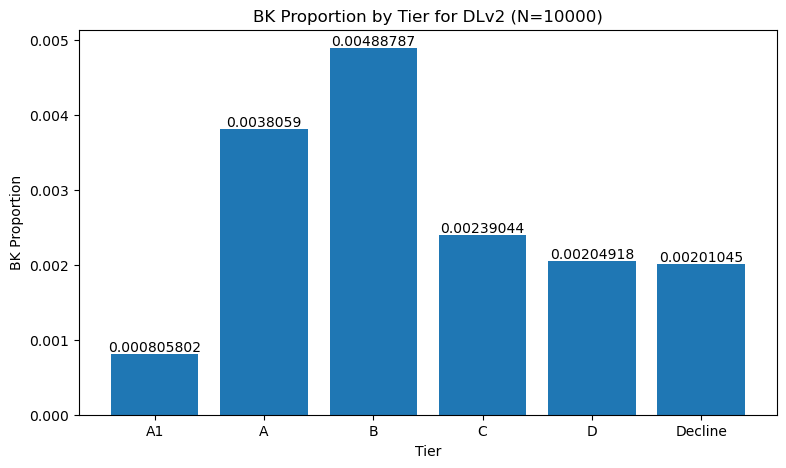

In [23]:
# # melt
# df_melted = df_tmp.melt(id_vars='Tier', var_name='BK prop', value_name='BK Proportion')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'BK Proportion by Tier for DLv2 (N={int_nrows})')
ax.set_ylabel('BK Proportion')
ax.set_xlabel('Tier')
bars = ax.bar(df_tmp['Tier'], df_tmp['dlv2_mean_bk_prop'])
ax.bar_label(bars)

# save
str_filename = 'plt_stacked_bk.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### Miles ODO

In [24]:
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'miles_odometer__app': 'mean',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'miles_odometer__app':'gen12_mean_miles_odometer'}, inplace=True)
# round to hundredth
df_tmp["gen12_mean_miles_odometer"] = df_tmp["gen12_mean_miles_odometer"].round(2)

df_tmp2 = df.groupby(by=['tier_dlv2'], as_index=False).agg({
    'miles_odometer__app': 'mean',
})

df_tmp2.rename(columns={'tier_dlv2':'Tier', 'miles_odometer__app':'dlv2_mean_miles_odometer'},  inplace=True)
# round to hundredth
df_tmp2["dlv2_mean_miles_odometer"] = df_tmp2["dlv2_mean_miles_odometer"].round(2)

In [25]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values

# show
df_tmp

,Tier,gen12_mean_miles_odometer,dlv2_mean_miles_odometer
0,A1,45742.97,39185.51
1,A,46303.60,42224.86
2,B,50541.18,49392.24
3,C,52772.78,55925.43
4,D,52546.77,55415.38
5,Decline,53783.62,62839.33


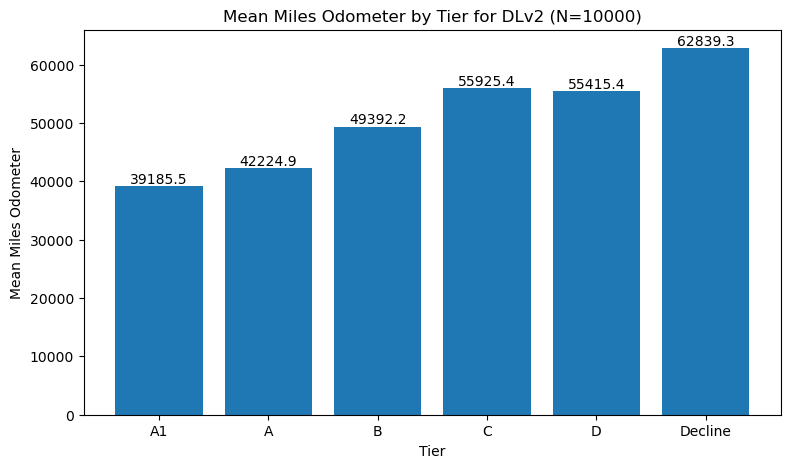

In [26]:
# melt
# df_melted = df_tmp.melt(id_vars='Tier', var_name='Mean Miles Odometer', value_name='Miles')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean Miles Odometer by Tier for DLv2 (N={int_nrows})')
ax.set_ylabel('Mean Miles Odometer')
ax.set_xlabel('Tier')
bars = ax.bar(df_tmp['Tier'], df_tmp['dlv2_mean_miles_odometer'])
ax.bar_label(bars)

# save
str_filename = 'plt_stacked_miles_odometer.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### Franchise tag

In [27]:
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'strdealershiptrackertype__app': 'mean',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'strdealershiptrackertype__app':'gen12_prop_franchise'}, inplace=True)

df_tmp2 = df.groupby(by=['tier_dlv2'], as_index=False).agg({
    'strdealershiptrackertype__app': 'mean',
})

df_tmp2.rename(columns={'tier_dlv2':'Tier', 'strdealershiptrackertype__app':'dlv2_prop_franchise'},  inplace=True)

In [28]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values

# show
df_tmp

,Tier,gen12_prop_franchise,dlv2_prop_franchise
0,A1,1.0,1.0
1,A,1.0,1.0
2,B,1.0,1.0
3,C,1.0,1.0
4,D,1.0,1.0
5,Decline,1.0,1.0


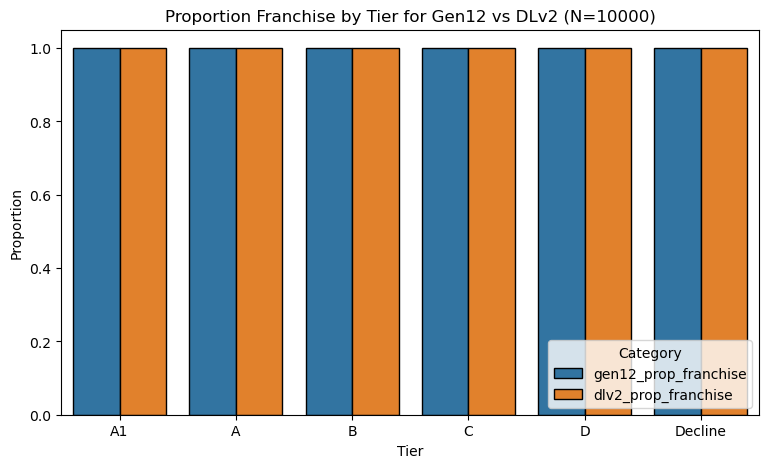

In [29]:
# melt
df_melted = df_tmp.melt(id_vars='Tier', var_name='Franchise Prop', value_name='Proportion')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Proportion Franchise by Tier for Gen12 vs DLv2 (N={int_nrows})')
sns.barplot(x='Tier', y='Proportion', hue='Franchise Prop', data=df_melted, estimator=sum, edgecolor='black')
plt.legend(title='Category', loc='lower right')

# save
str_filename = 'plt_stacked_franchise_prop.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### Prop tier model

In [30]:
# gen 12 tier
df_tmp = df.groupby("tier_gen12").count().reset_index()
df_tmp = df_tmp[['tier_gen12', 'accountid']]
df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values
df_tmp = df_tmp.rename(columns={'tier_gen12':'Tier', 'accountid':'tier_gen12'})
df_tmp["prop_gen12"] = df_tmp["tier_gen12"] / df_tmp["tier_gen12"].sum()

# gen 13 ter
df_tmp2 = df.groupby("tier_dlv2").count().reset_index()
df_tmp2 = df_tmp2[['tier_dlv2', 'accountid']]
df_tmp2.iloc[[0, 1]] = df_tmp2.iloc[[1, 0]].values
df_tmp2 = df_tmp2.rename(columns={'tier_dlv2':'Tier', 'accountid':'tier_dlv2'})
df_tmp2["prop_dlv2"] = df_tmp2["tier_dlv2"] / df_tmp2["tier_dlv2"].sum()
df_tmp2

# merge
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)
df_tmp

# get cols we need
list_cols = ['Tier', 'prop_gen12', 'prop_dlv2']
df_tmp = df_tmp[list_cols]

# rearrange cols
order_ = ["A1", "A", "B", "C", "D", "Decline"]

df_tmp["Tier"] = pd.Categorical(df_tmp["Tier"], categories=order_, ordered=True)
df_tmp = df_tmp.sort_values("Tier").reset_index(drop=True)

df_tmp

,Tier,prop_gen12,prop_dlv2
0,A1,0.0555,0.1241
1,A,0.0757,0.1051
2,B,0.2397,0.3478
3,C,0.1030,0.1255
4,D,0.0480,0.0488
5,Decline,0.4781,0.2487


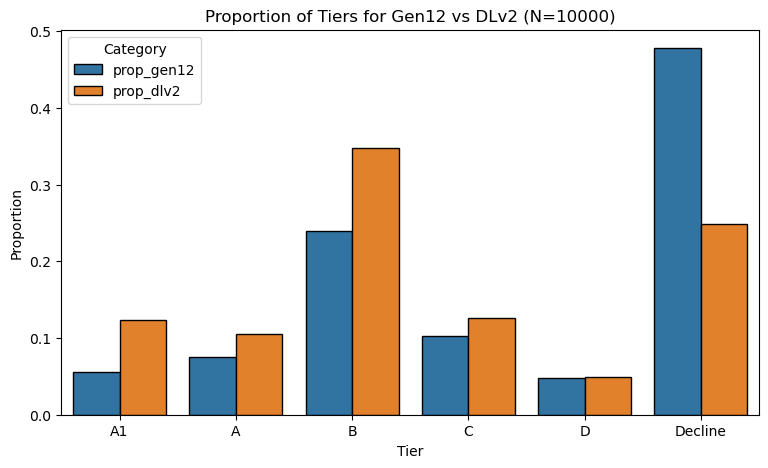

In [31]:
# melt
df_melted = df_tmp.melt(id_vars='Tier', var_name='Prop Tier', value_name='Proportion')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Proportion of Tiers for Gen12 vs DLv2 (N={int_nrows})')
sns.barplot(x='Tier', y='Proportion', hue='Prop Tier', data=df_melted, estimator=sum, edgecolor='black')
plt.legend(title='Category', loc='upper left')

# save
str_filename = 'plt_stacked_tier.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')